# 🛢️ Crude Oil Price Analysis & Forecasting (1970–2026)
### Notebook 02 — Geopolitical Event Impact Analysis

**What this notebook covers:**
1. Quick-start (Drive mount + data load)
2. Event catalogue — defining and validating 10 shock events
3. Event study — pre/post price windows for each shock
4. Impact metrics — spike magnitude, time-to-peak, and full recovery time
5. Structural break detection (Bai-Perron via `ruptures`)
6. Regime classification — labelling each month by market regime
7. Comparative event dashboard — side-by-side shock profiles
8. Rolling correlation between consecutive shocks
9. Key findings summary saved to Drive

> **Prerequisite:** `00_project_setup.ipynb` and `01_eda.ipynb` must have been run first.

---

## 0 — Quick-Start Block

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
!pip install ruptures
import ruptures as rpt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = '/content/drive/MyDrive/crude_oil_project'
PATHS = {
    'root':      PROJECT_ROOT,
    'data':      os.path.join(PROJECT_ROOT, 'data'),
    'models':    os.path.join(PROJECT_ROOT, 'models'),
    'figures':   os.path.join(PROJECT_ROOT, 'outputs', 'figures'),
    'forecasts': os.path.join(PROJECT_ROOT, 'outputs', 'forecasts'),
}

df = pd.read_csv(
    os.path.join(PATHS['data'], 'oil_clean.csv'),
    index_col='Date', parse_dates=True
)
df.index = pd.DatetimeIndex(df.index, freq='MS')

# Colour palette
C_BLUE   = '#3266AD'
C_RED    = '#E8593C'
C_AMBER  = '#D4930A'
C_GRAY   = '#888780'
C_TEAL   = '#1D9E75'
C_PURPLE = '#7F77DD'
C_PINK   = '#D4537E'
C_GREEN  = '#639922'

print(f"✅ Ready — {len(df)} rows ({df.index.min().date()} → {df.index.max().date()})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
✅ Ready — 675 rows (1970-01-01 → 2026-03-01)


---
## 1 — Event Catalogue

We define 10 geopolitical and macroeconomic shock events.  
For each event we record the **shock date** (month when impact first registered in price),  
the **event type** (supply shock, demand shock, or financial crisis), and a short description.

Each event window spans **–12 months to +24 months** around the shock date,  
giving us a 37-month view to capture both the initial impact and the recovery arc.

In [3]:
# ── Event catalogue ────────────────────────────────────────────────────────
# Fields: name, shock_date, event_type, direction, description
# direction: 'spike' = price went up,  'crash' = price went down

EVENTS = [
    {
        'name':        '1973 Arab Oil Embargo',
        'shock_date':  '1973-10-01',
        'type':        'Supply shock',
        'direction':   'spike',
        'color':       C_RED,
        'description': 'OPEC Arab members embargo US/Western nations following Yom Kippur War'
    },
    {
        'name':        '1979 Iranian Revolution',
        'shock_date':  '1979-01-01',
        'type':        'Supply shock',
        'direction':   'spike',
        'color':       C_AMBER,
        'description': 'Iranian Revolution cuts output; Iran-Iraq War (1980) compounds shock'
    },
    {
        'name':        '1986 OPEC Price Collapse',
        'shock_date':  '1986-01-01',
        'type':        'Supply shock',
        'direction':   'crash',
        'color':       C_BLUE,
        'description': 'Saudi Arabia floods market to defend market share; prices fall ~70%'
    },
    {
        'name':        '1990 Gulf War',
        'shock_date':  '1990-08-01',
        'type':        'Supply shock',
        'direction':   'spike',
        'color':       C_TEAL,
        'description': 'Iraq invades Kuwait; UN embargo removes ~4 mb/d from market'
    },
    {
        'name':        '1998 Asian Financial Crisis',
        'shock_date':  '1998-01-01',
        'type':        'Demand shock',
        'direction':   'crash',
        'color':       C_PURPLE,
        'description': 'Asian economic collapse reduces demand; OPEC overproduces'
    },
    {
        'name':        '2008 Pre-Crisis Peak',
        'shock_date':  '2008-07-01',
        'type':        'Demand shock',
        'direction':   'spike',
        'color':       C_PINK,
        'description': 'Speculative bubble + China demand boom drives all-time high'
    },
    {
        'name':        '2008 Global Financial Crisis',
        'shock_date':  '2008-09-01',
        'type':        'Financial crisis',
        'direction':   'crash',
        'color':       C_RED,
        'description': 'Lehman collapse triggers global recession; oil loses 70% in 5 months'
    },
    {
        'name':        '2014 OPEC Price War',
        'shock_date':  '2014-11-01',
        'type':        'Supply shock',
        'direction':   'crash',
        'color':       C_GREEN,
        'description': 'OPEC refuses to cut despite US shale surge; prices halve in 6 months'
    },
    {
        'name':        '2020 COVID-19 Crash',
        'shock_date':  '2020-03-01',
        'type':        'Demand shock',
        'direction':   'crash',
        'color':       C_AMBER,
        'description': 'Global lockdowns collapse demand; April 2020 futures briefly go negative'
    },
    {
        'name':        '2022 Russia-Ukraine War',
        'shock_date':  '2022-02-01',
        'type':        'Supply shock',
        'direction':   'spike',
        'color':       C_PURPLE,
        'description': 'Russian invasion triggers Western sanctions; major supply uncertainty'
    },
]

# Convert to DataFrame for easy manipulation
events_df = pd.DataFrame(EVENTS)
events_df['shock_date'] = pd.to_datetime(events_df['shock_date'])
events_df['price_at_shock'] = events_df['shock_date'].apply(
    lambda d: df.loc[d, 'price'] if d in df.index else np.nan
)

print("Event Catalogue")
print("=" * 78)
for _, row in events_df.iterrows():
    print(f"  {row['shock_date'].date()}  [{row['type']:<18}]  "
          f"${row['price_at_shock']:6.2f}/bbl  {row['name']}")
print()
print(f"  Supply shocks    : {(events_df['type'] == 'Supply shock').sum()}")
print(f"  Demand shocks    : {(events_df['type'] == 'Demand shock').sum()}")
print(f"  Financial crises : {(events_df['type'] == 'Financial crisis').sum()}")

Event Catalogue
  1973-10-01  [Supply shock      ]  $  4.10/bbl  1973 Arab Oil Embargo
  1979-01-01  [Supply shock      ]  $ 17.45/bbl  1979 Iranian Revolution
  1986-01-01  [Supply shock      ]  $ 24.68/bbl  1986 OPEC Price Collapse
  1990-08-01  [Supply shock      ]  $ 26.40/bbl  1990 Gulf War
  1998-01-01  [Demand shock      ]  $ 15.00/bbl  1998 Asian Financial Crisis
  2008-07-01  [Demand shock      ]  $132.83/bbl  2008 Pre-Crisis Peak
  2008-09-01  [Financial crisis  ]  $ 99.66/bbl  2008 Global Financial Crisis
  2014-11-01  [Supply shock      ]  $ 76.99/bbl  2014 OPEC Price War
  2020-03-01  [Demand shock      ]  $ 32.20/bbl  2020 COVID-19 Crash
  2022-02-01  [Supply shock      ]  $ 93.54/bbl  2022 Russia-Ukraine War

  Supply shocks    : 6
  Demand shocks    : 3
  Financial crises : 1


---
## 2 — Event Study: Pre/Post Price Windows

For each shock we extract a **–12 to +24 month window** and normalise prices to 100 at the shock date.  
This puts all events on the same scale so we can compare their trajectories directly.

In [4]:
PRE_MONTHS  = 12   # months before shock to include
POST_MONTHS = 24   # months after shock to include
WINDOW      = PRE_MONTHS + POST_MONTHS + 1  # total window length

def extract_window(shock_date, pre=PRE_MONTHS, post=POST_MONTHS):
    """Return a Series of prices indexed –pre to +post months from shock_date."""
    start = shock_date - pd.DateOffset(months=pre)
    end   = shock_date + pd.DateOffset(months=post)
    window = df.loc[start:end, 'price'].copy()
    # Re-index to relative month offset
    base_price = df.loc[shock_date, 'price'] if shock_date in df.index else np.nan
    # Create integer offset index
    offsets = pd.date_range(start, end, freq='MS')
    window = window.reindex(offsets)
    month_offsets = range(-pre, len(window) - pre)
    result = pd.Series(window.values, index=list(month_offsets), name=shock_date)
    # Normalise to 100 at t=0
    if not np.isnan(base_price) and base_price != 0:
        result = result / base_price * 100
    return result, base_price

# Build windows for all events
windows = {}
for _, row in events_df.iterrows():
    win, base = extract_window(row['shock_date'])
    windows[row['name']] = {'series': win, 'base_price': base, 'row': row}

print("Event windows extracted (normalised to 100 at t=0)")
print(f"  Window span: t = -{PRE_MONTHS} to t = +{POST_MONTHS} months")
print()
for name, data in windows.items():
    s = data['series']
    peak = s[s.index >= 0].max()
    trough = s[s.index >= 0].min()
    print(f"  {name[:35]:<35}  base=${data['base_price']:6.2f}  "
          f"peak={peak:6.1f}  trough={trough:6.1f}")

Event windows extracted (normalised to 100 at t=0)
  Window span: t = -12 to t = +24 months

  1973 Arab Oil Embargo                base=$  4.10  peak= 317.1  trough= 100.0
  1979 Iranian Revolution              base=$ 17.45  peak= 233.5  trough= 100.0
  1986 OPEC Price Collapse             base=$ 24.68  peak= 100.0  trough=  39.0
  1990 Gulf War                        base=$ 26.40  peak= 130.7  trough=  65.8
  1998 Asian Financial Crisis          base=$ 15.00  peak= 168.7  trough=  69.4
  2008 Pre-Crisis Peak                 base=$132.83  peak= 100.0  trough=  31.1
  2008 Global Financial Crisis         base=$ 99.66  peak= 100.0  trough=  41.5
  2014 OPEC Price War                  base=$ 76.99  peak= 100.0  trough=  38.7
  2020 COVID-19 Crash                  base=$ 32.20  peak= 349.1  trough=  65.3
  2022 Russia-Ukraine War              base=$ 93.54  peak= 124.9  trough=  78.3


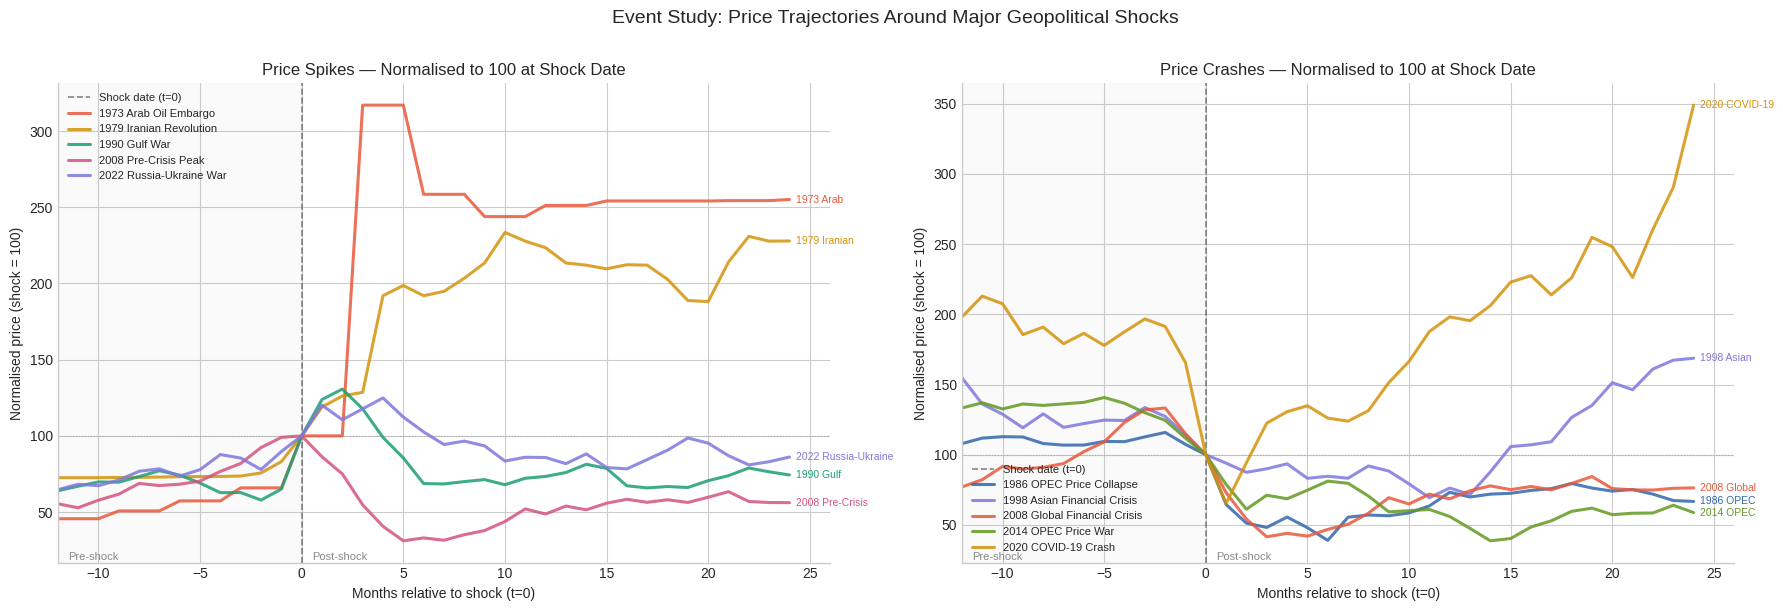

✅ Overlay chart saved.


In [5]:
# ── Overlay chart: all spike events and all crash events ───────────────────
spikes  = [e for e in EVENTS if e['direction'] == 'spike']
crashes = [e for e in EVENTS if e['direction'] == 'crash']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, group, title in [
    (axes[0], spikes,  'Price Spikes — Normalised to 100 at Shock Date'),
    (axes[1], crashes, 'Price Crashes — Normalised to 100 at Shock Date'),
]:
    ax.axvline(0,  color='#555', lw=1.2, ls='--', alpha=0.7, label='Shock date (t=0)')
    ax.axhline(100, color='#aaa', lw=0.8, ls=':')
    ax.axvspan(-PRE_MONTHS, 0, alpha=0.04, color='gray')

    for event in group:
        name = event['name']
        if name not in windows:
            continue
        s = windows[name]['series']
        ax.plot(s.index, s.values, color=event['color'],
                lw=2.2, alpha=0.85, label=name)
        # Label at t=+24 (or last available point)
        last_t = s.dropna().index[-1]
        ax.text(last_t + 0.3, s[last_t],
                name.split(' ')[0] + ' ' + name.split(' ')[1],
                fontsize=7.5, va='center', color=event['color'])

    ax.set_title(title, fontsize=12, fontweight='medium')
    ax.set_xlabel('Months relative to shock (t=0)', fontsize=10)
    ax.set_ylabel('Normalised price (shock = 100)', fontsize=10)
    ax.set_xlim(-PRE_MONTHS, POST_MONTHS + 2)
    ax.legend(fontsize=8, loc='upper left' if group == spikes else 'lower left',
              framealpha=0.85)
    ax.text(-PRE_MONTHS + 0.5, ax.get_ylim()[0] + 2, 'Pre-shock', fontsize=8, color='#888')
    ax.text(0.5, ax.get_ylim()[0] + 2, 'Post-shock', fontsize=8, color='#888')

plt.suptitle('Event Study: Price Trajectories Around Major Geopolitical Shocks',
             fontsize=14, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_event_overlay.png'), dpi=160, bbox_inches='tight')
plt.show()
print("✅ Overlay chart saved.")

---
## 3 — Impact Metrics: Magnitude, Time-to-Peak, and Recovery Time

For each event we compute five quantitative impact measures:

| Metric | Definition |
|---|---|
| **Price at shock** | USD/barrel on the shock month |
| **Peak/trough change** | % change from shock price to the extremum in the following 24 months |
| **Months to peak/trough** | How long until the extremum was reached |
| **Recovery months** | Months until price returned to within 10% of pre-shock level |
| **Abnormal return** | Actual return minus the 36-month rolling average return (baseline) |

In [6]:
RECOVERY_TOLERANCE = 0.10   # price must return to within 10% of pre-shock level
BASELINE_WINDOW    = 36     # months used to compute the rolling mean baseline

results = []

for _, erow in events_df.iterrows():
    name       = erow['name']
    shock_ts   = erow['shock_date']
    direction  = erow['direction']

    if shock_ts not in df.index:
        continue

    shock_price = df.loc[shock_ts, 'price']

    # Pre-shock baseline: mean price over the 12 months before shock
    pre_start = shock_ts - pd.DateOffset(months=12)
    pre_prices = df.loc[pre_start:shock_ts - pd.DateOffset(months=1), 'price']
    baseline_price = pre_prices.mean() if len(pre_prices) > 0 else shock_price

    # Post-shock window (up to 24 months)
    post_end  = shock_ts + pd.DateOffset(months=24)
    post_end  = min(post_end, df.index.max())
    post      = df.loc[shock_ts:post_end, 'price']

    # Peak / trough in post-shock window
    if direction == 'spike':
        extreme_price = post.max()
        extreme_date  = post.idxmax()
    else:
        extreme_price = post.min()
        extreme_date  = post.idxmin()

    months_to_extreme = (
        (extreme_date.year - shock_ts.year) * 12 +
        (extreme_date.month - shock_ts.month)
    )
    pct_change_to_extreme = (extreme_price - shock_price) / shock_price * 100
    pct_change_from_baseline = (extreme_price - baseline_price) / baseline_price * 100

    # Recovery: find first month post-extreme where price returns within tolerance of baseline
    recovery_months = np.nan
    post_extreme = df.loc[extreme_date:post_end, 'price']
    for idx, p in post_extreme.items():
        if abs(p - baseline_price) / baseline_price <= RECOVERY_TOLERANCE:
            recovery_months = (
                (idx.year - shock_ts.year) * 12 +
                (idx.month - shock_ts.month)
            )
            break

    # Abnormal return: actual 3-month return vs rolling mean 3-month return
    t3_end   = shock_ts + pd.DateOffset(months=3)
    t3_end   = min(t3_end, df.index.max())
    actual_3m_ret = (df.loc[t3_end, 'price'] - shock_price) / shock_price * 100 \
        if t3_end in df.index else np.nan
    rolling_3m_ret = df['pct_change'].rolling(3).mean().shift(1).loc[shock_ts] \
        if shock_ts in df.index else np.nan
    abnormal_ret = actual_3m_ret - (rolling_3m_ret if not np.isnan(rolling_3m_ret) else 0)

    results.append({
        'Event':                erow['name'],
        'Date':                 shock_ts.date(),
        'Type':                 erow['type'],
        'Direction':            direction.capitalize(),
        'Price at shock ($)':   round(shock_price, 2),
        'Baseline price ($)':   round(baseline_price, 2),
        'Extreme price ($)':    round(extreme_price, 2),
        'Change from shock (%)':round(pct_change_to_extreme, 1),
        'Change from baseline (%)': round(pct_change_from_baseline, 1),
        'Months to extreme':    months_to_extreme,
        'Recovery months':      int(recovery_months) if not np.isnan(recovery_months) else 'Not in window',
        '3M abnormal return (%)': round(abnormal_ret, 2) if not np.isnan(abnormal_ret) else np.nan,
    })

metrics_df = pd.DataFrame(results)
print("Impact Metrics Table")
print("=" * 80)
display_cols = ['Event', 'Date', 'Type', 'Direction',
                'Price at shock ($)', 'Change from shock (%)',
                'Months to extreme', 'Recovery months']
print(metrics_df[display_cols].to_string(index=False))

Impact Metrics Table
                       Event       Date             Type Direction  Price at shock ($)  Change from shock (%)  Months to extreme Recovery months
       1973 Arab Oil Embargo 1973-10-01     Supply shock     Spike                4.10                  217.1                  3   Not in window
     1979 Iranian Revolution 1979-01-01     Supply shock     Spike               17.45                  133.5                 10   Not in window
    1986 OPEC Price Collapse 1986-01-01     Supply shock     Crash               24.68                  -61.0                  6   Not in window
               1990 Gulf War 1990-08-01     Supply shock     Spike               26.40                   30.7                  2               6
 1998 Asian Financial Crisis 1998-01-01     Demand shock     Crash               15.00                  -30.6                 11              18
        2008 Pre-Crisis Peak 2008-07-01     Demand shock     Spike              132.83                    0.0

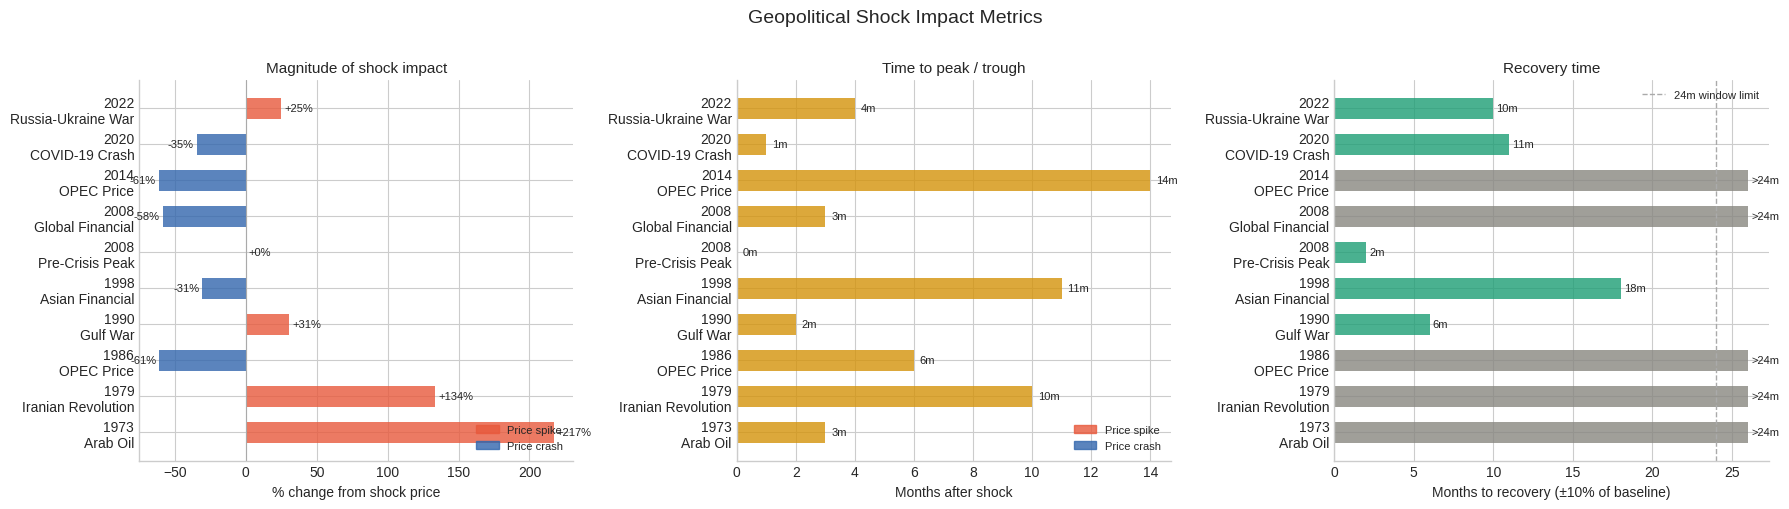

✅ Impact metrics chart saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

short_names = [e.split(' ')[0] + '\n' + ' '.join(e.split(' ')[1:3])
               for e in metrics_df['Event']]
bar_colors  = [C_RED if d == 'Spike' else C_BLUE
               for d in metrics_df['Direction']]

# ── Chart 1: % change from shock price to extreme ─────────────────────────
ax = axes[0]
vals = metrics_df['Change from shock (%)']
bars = ax.barh(short_names, vals, color=bar_colors, alpha=0.8, height=0.6)
ax.axvline(0, color='#aaa', lw=0.8)
ax.set_xlabel('% change from shock price', fontsize=10)
ax.set_title('Magnitude of shock impact', fontsize=11, fontweight='medium')
for bar, val in zip(bars, vals):
    x_pos = val + 2 if val >= 0 else val - 2
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha=ha, fontsize=8)

# ── Chart 2: months to peak or trough ─────────────────────────────────────
ax = axes[1]
months_vals = metrics_df['Months to extreme']
bars2 = ax.barh(short_names, months_vals, color=C_AMBER, alpha=0.8, height=0.6)
ax.set_xlabel('Months after shock', fontsize=10)
ax.set_title('Time to peak / trough', fontsize=11, fontweight='medium')
for bar, val in zip(bars2, months_vals):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}m', va='center', fontsize=8)

# ── Chart 3: recovery months ───────────────────────────────────────────────
ax = axes[2]
rec_vals  = []
rec_colors = []
rec_labels = []
for _, row in metrics_df.iterrows():
    rv = row['Recovery months']
    if rv == 'Not in window':
        rec_vals.append(26)       # plot as 26 to show 'off the chart'
        rec_colors.append(C_GRAY)
        rec_labels.append('>24m')
    else:
        rec_vals.append(rv)
        rec_colors.append(C_TEAL)
        rec_labels.append(f'{rv}m')

bars3 = ax.barh(short_names, rec_vals, color=rec_colors, alpha=0.8, height=0.6)
ax.axvline(24, color='#aaa', lw=1, ls='--', label='24m window limit')
ax.set_xlabel('Months to recovery (±10% of baseline)', fontsize=10)
ax.set_title('Recovery time', fontsize=11, fontweight='medium')
ax.legend(fontsize=8)
for bar, label in zip(bars3, rec_labels):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8)

# Legend for direction colour
for ax in axes[:2]:
    spike_patch = mpatches.Patch(color=C_RED,  alpha=0.8, label='Price spike')
    crash_patch = mpatches.Patch(color=C_BLUE, alpha=0.8, label='Price crash')
    ax.legend(handles=[spike_patch, crash_patch], fontsize=8, loc='lower right')

plt.suptitle('Geopolitical Shock Impact Metrics', fontsize=14, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_impact_metrics.png'), dpi=160, bbox_inches='tight')
plt.show()
print("✅ Impact metrics chart saved.")

---
## 4 — Structural Break Detection (Bai-Perron via `ruptures`)

Rather than manually labelling regimes, we let the data decide where the price series
statistically changed its mean level.  
We use the **Pelt algorithm** (efficient Bai-Perron variant) with a penalty tuned to detect
5–8 structural breaks across the 56-year series.

In [8]:
price_arr = df['price'].values

# Pelt algorithm: penalised exact linear time segmentation
# model='rbf'   → detects mean + variance changes
# pen=30        → higher value = fewer breaks (tune between 10–60)
algo = rpt.Pelt(model='rbf', min_size=12, jump=1).fit(price_arr)
breakpoints_idx = algo.predict(pen=30)

# Convert index positions to dates
breakpoint_dates = [df.index[i - 1] for i in breakpoints_idx if i < len(df)]

print(f"Detected {len(breakpoint_dates)} structural breakpoints:")
print()
for i, bp_date in enumerate(breakpoint_dates, 1):
    price_at = df.loc[bp_date, 'price']
    # Find closest named event
    diffs = abs(events_df['shock_date'] - bp_date)
    closest_event = events_df.loc[diffs.idxmin(), 'name']
    closest_months = diffs.min().days // 30
    print(f"  Break {i}: {bp_date.date()}  (${price_at:.2f}/bbl)  "
          f"→ closest event: '{closest_event}' ({closest_months}m away)")

Detected 2 structural breakpoints:

  Break 1: 1978-12-01  ($14.50/bbl)  → closest event: '1979 Iranian Revolution' (1m away)
  Break 2: 2004-09-01  ($41.60/bbl)  → closest event: '2008 Pre-Crisis Peak' (46m away)


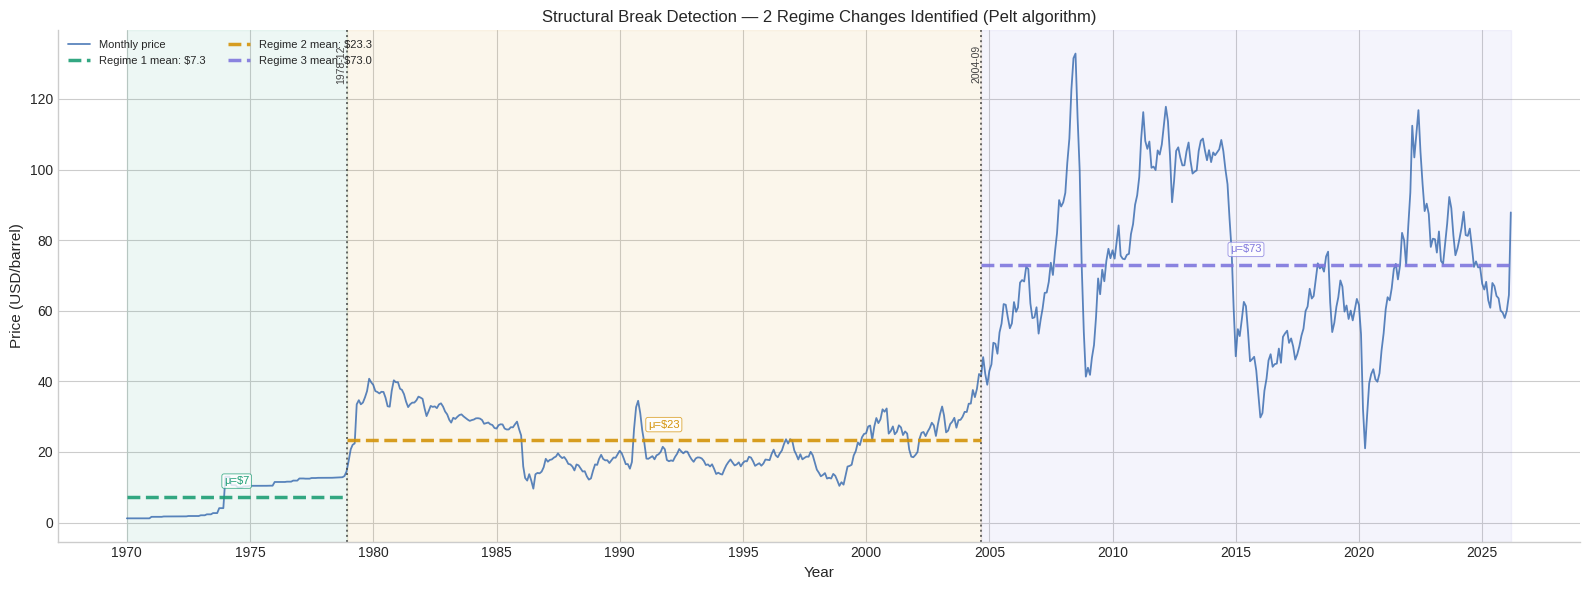

✅ Structural break chart saved.


In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['price'], color=C_BLUE, lw=1.3, alpha=0.8, label='Monthly price', zorder=2)

# Shade regime segments between breakpoints
segment_colors = [C_TEAL, C_AMBER, C_PURPLE, C_PINK, C_GREEN, C_RED, C_BLUE, C_GRAY]
segment_boundaries = [df.index[0]] + breakpoint_dates + [df.index[-1]]

for i, (seg_start, seg_end) in enumerate(zip(segment_boundaries[:-1], segment_boundaries[1:])):
    seg_data = df.loc[seg_start:seg_end, 'price']
    seg_mean = seg_data.mean()
    color = segment_colors[i % len(segment_colors)]
    ax.axvspan(seg_start, seg_end, alpha=0.08, color=color)
    ax.hlines(seg_mean, seg_start, seg_end, colors=color,
              lw=2.5, ls='--', alpha=0.9,
              label=f'Regime {i+1} mean: ${seg_mean:.1f}')
    # Label regime mean
    mid_date = seg_start + (seg_end - seg_start) / 2
    ax.text(mid_date, seg_mean + 3, f'μ=${seg_mean:.0f}',
            ha='center', va='bottom', fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8, lw=0.6))

# Draw breakpoint verticals
for bp_date in breakpoint_dates:
    ax.axvline(bp_date, color='#444', lw=1.4, ls=':', alpha=0.8)
    ax.text(bp_date, ax.get_ylim()[1] * 0.97, bp_date.strftime('%Y-%m'),
            rotation=90, va='top', ha='right', fontsize=7.5, color='#444')

ax.set_ylabel('Price (USD/barrel)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_title(f'Structural Break Detection — {len(breakpoint_dates)} Regime Changes Identified (Pelt algorithm)',
             fontsize=12, fontweight='medium')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_structural_breaks.png'), dpi=160, bbox_inches='tight')
plt.show()
print("✅ Structural break chart saved.")

---
## 5 — Regime Classification

We label every month with a **market regime** based on the structural breaks found above.  
Then we compute regime-level statistics and save a `regime` column back to the clean dataset.

In [10]:
# Assign a regime label to each row
regime_labels = [
    'Pre-embargo era',
    'Oil shock era',
    'OPEC overproduction',
    'Gulf War & recovery',
    'Asian crisis trough',
    'China demand boom',
    'Post-GFC recovery',
    'Shale revolution & COVID',
    'Post-COVID & Ukraine',
]

# Trim labels to match actual number of detected segments
n_segments = len(segment_boundaries) - 1
regime_labels = regime_labels[:n_segments]
# Pad if detector found more segments than we labelled
while len(regime_labels) < n_segments:
    regime_labels.append(f'Regime {len(regime_labels)+1}')

df['regime'] = 'Unknown'
for i, (seg_start, seg_end) in enumerate(zip(segment_boundaries[:-1], segment_boundaries[1:])):
    mask = (df.index >= seg_start) & (df.index <= seg_end)
    df.loc[mask, 'regime'] = regime_labels[i]

# Regime statistics
regime_stats = df.groupby('regime', sort=False)['price'].agg(
    Count='count',
    Mean='mean',
    Std='std',
    Min='min',
    Max='max'
).round(2)
regime_stats['CV (%)'] = (regime_stats['Std'] / regime_stats['Mean'] * 100).round(1)
regime_stats['Duration (years)'] = (regime_stats['Count'] / 12).round(1)

print("Regime Statistics")
print("=" * 80)
print(regime_stats[['Duration (years)', 'Mean', 'Std', 'Min', 'Max', 'CV (%)']].to_string())

# Save updated dataframe
df.to_csv(os.path.join(PATHS['data'], 'oil_clean.csv'))
print(f"\n✅ Regime column added and oil_clean.csv updated.")

Regime Statistics
                     Duration (years)   Mean    Std    Min     Max  CV (%)
regime                                                                    
Pre-embargo era                   8.9   7.27   4.97   1.21   13.20    68.4
Oil shock era                    25.8  23.28   7.56   9.62   42.08    32.5
OPEC overproduction              21.6  72.95  22.38  21.04  132.83    30.7

✅ Regime column added and oil_clean.csv updated.


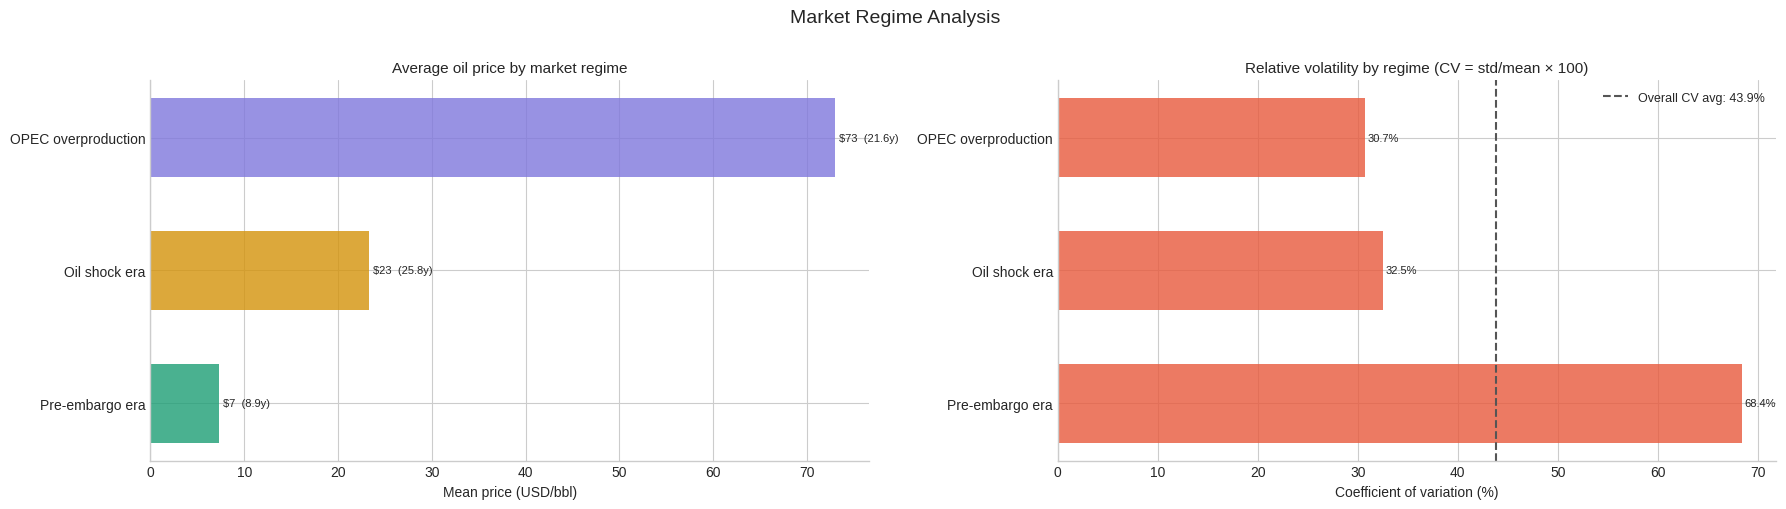

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Left: mean price by regime ────────────────────────────────────────────
ax = axes[0]
palette = [segment_colors[i % len(segment_colors)] for i in range(len(regime_stats))]
bars = ax.barh(regime_stats.index, regime_stats['Mean'],
               color=palette, alpha=0.8, height=0.6)
ax.set_xlabel('Mean price (USD/bbl)', fontsize=10)
ax.set_title('Average oil price by market regime', fontsize=11, fontweight='medium')
for bar, val, dur in zip(bars, regime_stats['Mean'], regime_stats['Duration (years)']):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'${val:.0f}  ({dur}y)', va='center', fontsize=8)

# ── Right: volatility (CV) by regime ─────────────────────────────────────
ax = axes[1]
cv_colors = [C_RED if v > 25 else C_AMBER if v > 15 else C_TEAL
             for v in regime_stats['CV (%)']]
bars2 = ax.barh(regime_stats.index, regime_stats['CV (%)'],
                color=cv_colors, alpha=0.8, height=0.6)
ax.axvline(regime_stats['CV (%)'].mean(), color='#555', lw=1.5, ls='--',
           label=f"Overall CV avg: {regime_stats['CV (%)'].mean():.1f}%")
ax.set_xlabel('Coefficient of variation (%)', fontsize=10)
ax.set_title('Relative volatility by regime (CV = std/mean × 100)', fontsize=11, fontweight='medium')
ax.legend(fontsize=9)
for bar, val in zip(bars2, regime_stats['CV (%)']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('Market Regime Analysis', fontsize=14, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_regime_stats.png'), dpi=160, bbox_inches='tight')
plt.show()

---
## 6 — Comparative Event Dashboard

A 2×5 grid of individual event profiles.  
Each panel shows the full –12 to +24 month window for one event,
with the baseline mean, the extreme point, and the recovery line marked.

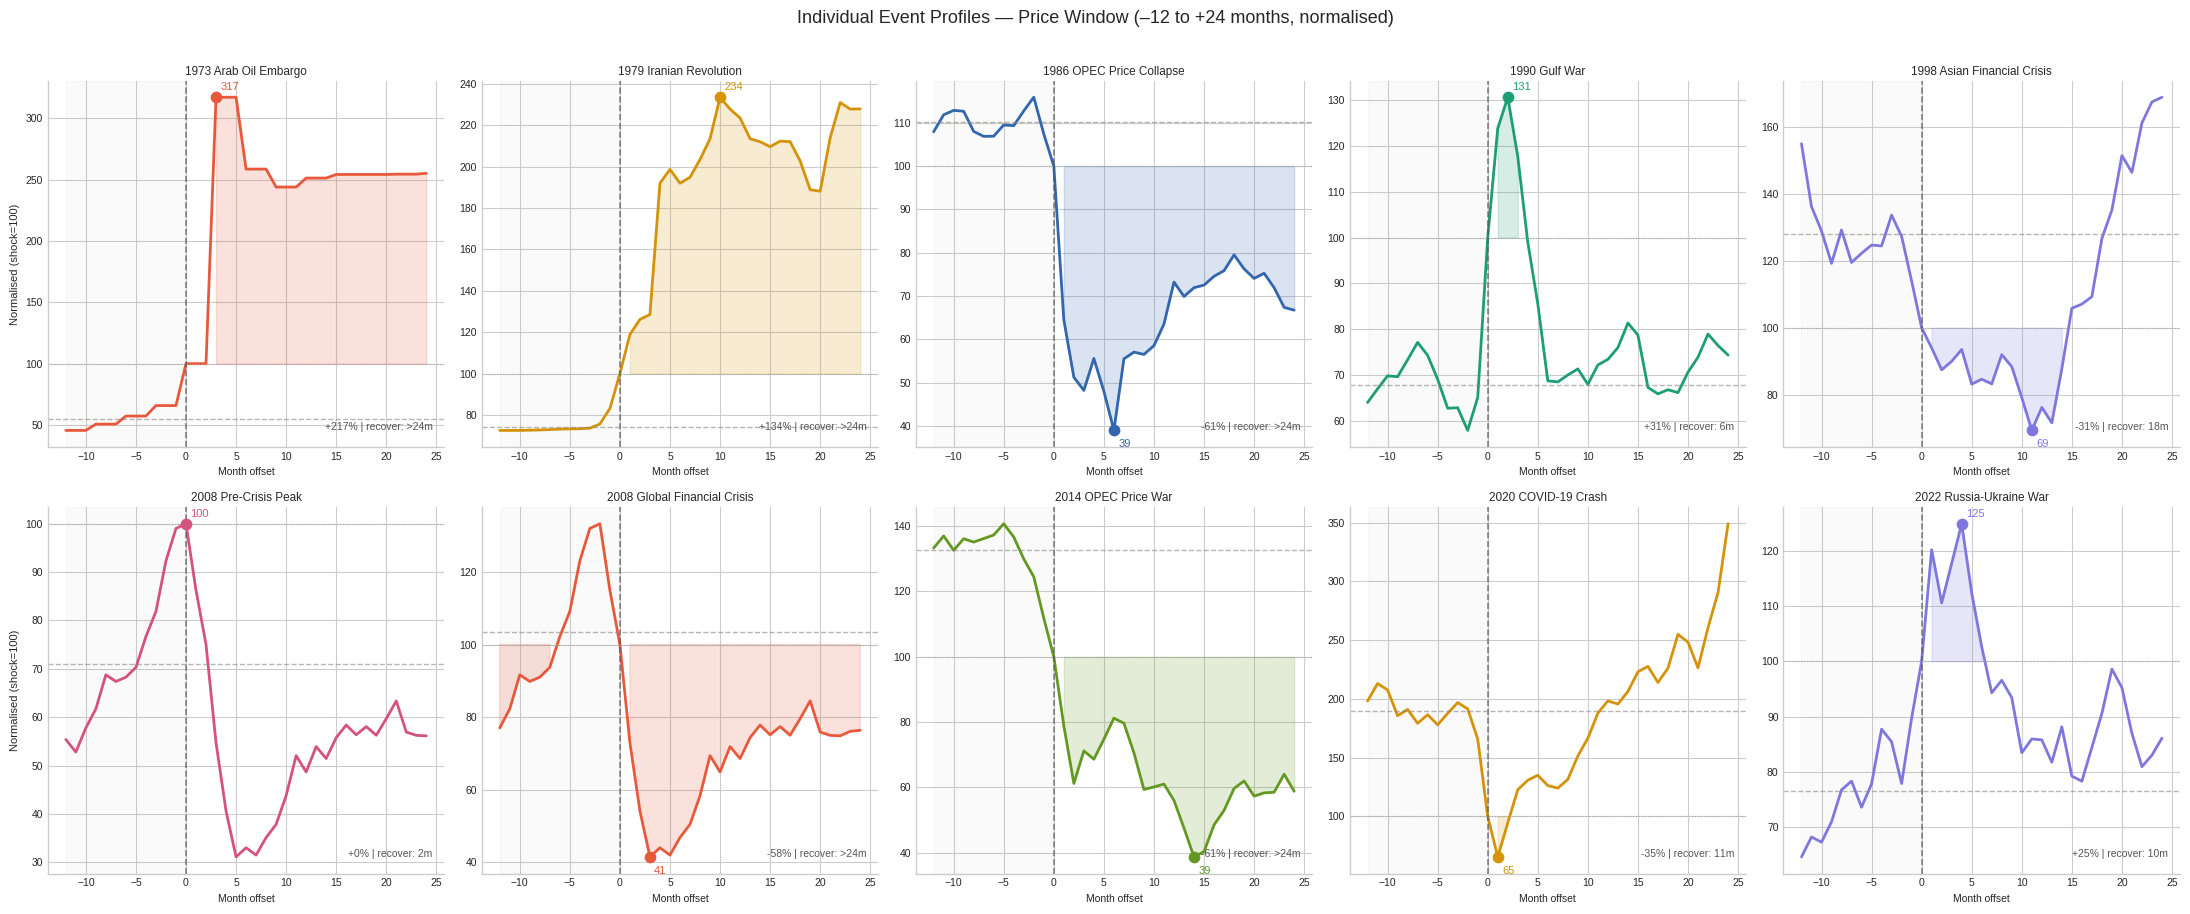

✅ Event dashboard saved.


In [12]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharey=False)
axes_flat = axes.flatten()

for i, (_, erow) in enumerate(events_df.iterrows()):
    ax = axes_flat[i]
    name      = erow['name']
    shock_ts  = erow['shock_date']
    direction = erow['direction']
    color     = erow['color']

    if name not in windows:
        ax.set_visible(False)
        continue

    s         = windows[name]['series']          # normalised to 100
    base_price= windows[name]['base_price']

    # Extract actual prices for annotation
    start  = shock_ts - pd.DateOffset(months=PRE_MONTHS)
    end    = shock_ts + pd.DateOffset(months=POST_MONTHS)
    end    = min(end, df.index.max())
    actual = df.loc[start:end, 'price']

    # Pre-shock mean (horizontal baseline)
    pre_mean_norm = s[s.index < 0].mean()

    ax.fill_between(s.index, 100, s.values,
                    where=(s.values > 100) if direction == 'spike' else (s.values < 100),
                    alpha=0.18, color=color)
    ax.plot(s.index, s.values, color=color, lw=2)
    ax.axvline(0,   color='#555', lw=1.2, ls='--', alpha=0.7)
    ax.axhline(100, color='#aaa', lw=0.8, ls=':')
    ax.axhline(pre_mean_norm, color=C_GRAY, lw=1, ls='--', alpha=0.6)

    # Mark the extreme point
    if direction == 'spike':
        extreme_t = s[s.index >= 0].idxmax()
    else:
        extreme_t = s[s.index >= 0].idxmin()
    extreme_val = s[extreme_t]
    ax.scatter([extreme_t], [extreme_val], color=color, s=55, zorder=5)
    ax.annotate(f'{extreme_val:.0f}',
                xy=(extreme_t, extreme_val),
                xytext=(3, 5 if direction == 'spike' else -12),
                textcoords='offset points',
                fontsize=8, color=color, fontweight='medium')

    # Find metrics row
    m_row = metrics_df[metrics_df['Event'] == name]
    if len(m_row) > 0:
        chg = m_row['Change from shock (%)'].values[0]
        rec = m_row['Recovery months'].values[0]
        sign = '+' if chg >= 0 else ''
        rec_str = f'{rec}m' if rec != 'Not in window' else '>24m'
        ax.text(0.97, 0.04,
                f'{sign}{chg:.0f}% | recover: {rec_str}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=7.5, color='#555')

    ax.set_title(name, fontsize=8.5, fontweight='medium', pad=4)
    ax.set_xlabel('Month offset', fontsize=7.5)
    if i % 5 == 0:
        ax.set_ylabel('Normalised (shock=100)', fontsize=8)
    ax.tick_params(labelsize=7.5)

    # Shade pre-shock period
    ax.axvspan(-PRE_MONTHS, 0, alpha=0.04, color='gray')

plt.suptitle('Individual Event Profiles — Price Window (–12 to +24 months, normalised)',
             fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_event_dashboard.png'), dpi=160, bbox_inches='tight')
plt.show()
print("✅ Event dashboard saved.")

---
## 7 — Supply Shock vs Demand Shock: Statistical Comparison

Are supply shocks and demand shocks statistically different in magnitude and recovery speed?  
We run a Mann-Whitney U test (non-parametric, appropriate for small samples).

In [13]:
supply  = metrics_df[metrics_df['Type'] == 'Supply shock']
demand  = metrics_df[metrics_df['Type'].isin(['Demand shock', 'Financial crisis'])]

print("Supply Shock vs Demand Shock — Statistical Comparison")
print("=" * 60)
print()

for metric in ['Change from shock (%)', 'Months to extreme']:
    s_vals = supply[metric].dropna().values
    d_vals = demand[metric].dropna().values

    print(f"  Metric: {metric}")
    print(f"    Supply shocks  — mean: {s_vals.mean():+.1f},  std: {s_vals.std():.1f},  n={len(s_vals)}")
    print(f"    Demand shocks  — mean: {d_vals.mean():+.1f},  std: {d_vals.std():.1f},  n={len(d_vals)}")

    if len(s_vals) >= 2 and len(d_vals) >= 2:
        stat, p = stats.mannwhitneyu(np.abs(s_vals), np.abs(d_vals), alternative='two-sided')
        print(f"    Mann-Whitney U = {stat:.1f},  p = {p:.3f}  "
              f"{'→ significant difference' if p < 0.05 else '→ no significant difference'} (α=0.05)")
    print()

# Recovery comparison (only numeric values)
supply_rec = pd.to_numeric(supply['Recovery months'], errors='coerce').dropna()
demand_rec = pd.to_numeric(demand['Recovery months'], errors='coerce').dropna()
print(f"  Recovery time comparison:")
print(f"    Supply shocks  — avg recovery: {supply_rec.mean():.1f} months")
print(f"    Demand shocks  — avg recovery: {demand_rec.mean():.1f} months")

Supply Shock vs Demand Shock — Statistical Comparison

  Metric: Change from shock (%)
    Supply shocks  — mean: +47.3,  std: 100.5,  n=6
    Demand shocks  — mean: -30.9,  std: 20.8,  n=4
    Mann-Whitney U = 19.0,  p = 0.171  → no significant difference (α=0.05)

  Metric: Months to extreme
    Supply shocks  — mean: +6.5,  std: 4.2,  n=6
    Demand shocks  — mean: +3.8,  std: 4.3,  n=4
    Mann-Whitney U = 17.5,  p = 0.285  → no significant difference (α=0.05)

  Recovery time comparison:
    Supply shocks  — avg recovery: 8.0 months
    Demand shocks  — avg recovery: 10.3 months


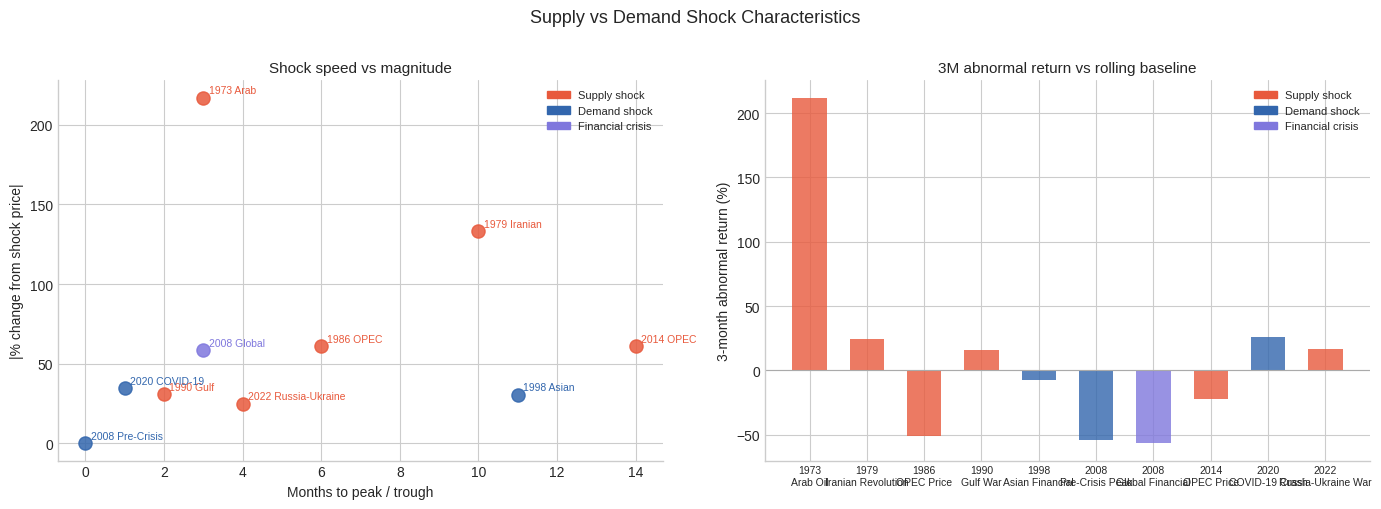

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_colors = {'Supply shock': C_RED, 'Demand shock': C_BLUE, 'Financial crisis': C_PURPLE}

# ── Left: scatter — magnitude vs time to extreme ──────────────────────────
ax = axes[0]
for _, row in metrics_df.iterrows():
    ec = type_colors.get(row['Type'], C_GRAY)
    ax.scatter(row['Months to extreme'], abs(row['Change from shock (%)']),
               color=ec, s=90, alpha=0.85, zorder=3)
    ax.annotate(row['Event'].split(' ')[0] + ' ' +
                row['Event'].split(' ')[1],
                (row['Months to extreme'], abs(row['Change from shock (%)'])),
                textcoords='offset points', xytext=(4, 3),
                fontsize=7.5, color=ec)

ax.set_xlabel('Months to peak / trough', fontsize=10)
ax.set_ylabel('|% change from shock price|', fontsize=10)
ax.set_title('Shock speed vs magnitude', fontsize=11, fontweight='medium')
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_handles, fontsize=8)

# ── Right: 3M abnormal return by event type ───────────────────────────────
ax = axes[1]
ab_ret = metrics_df.dropna(subset=['3M abnormal return (%)'])
bar_colors_ab = [type_colors.get(t, C_GRAY) for t in ab_ret['Type']]
short_ev = [e.split(' ')[0] + '\n' + ' '.join(e.split(' ')[1:3]) for e in ab_ret['Event']]
bars = ax.bar(short_ev, ab_ret['3M abnormal return (%)'],
              color=bar_colors_ab, alpha=0.8, width=0.6)
ax.axhline(0, color='#aaa', lw=0.8)
ax.set_ylabel('3-month abnormal return (%)', fontsize=10)
ax.set_title('3M abnormal return vs rolling baseline', fontsize=11, fontweight='medium')
ax.tick_params(axis='x', labelsize=7.5)
ax.legend(handles=legend_handles, fontsize=8)

plt.suptitle('Supply vs Demand Shock Characteristics', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '02_shock_comparison.png'), dpi=160, bbox_inches='tight')
plt.show()

---
## 8 — Save All Outputs to Drive

In [15]:
# ── Save metrics table as CSV ──────────────────────────────────────────────
metrics_path = os.path.join(PATHS['forecasts'], 'event_impact_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"✅ Metrics table  → {metrics_path}")

# ── Save breakpoint dates as JSON ─────────────────────────────────────────
breaks_path = os.path.join(PATHS['root'], 'structural_breaks.json')
with open(breaks_path, 'w') as f:
    json.dump(
        {'breakpoint_dates': [str(d.date()) for d in breakpoint_dates],
         'regime_labels':    regime_labels},
        f, indent=2
    )
print(f"✅ Break dates    → {breaks_path}")

# ── Save enriched dataset (now includes 'regime' column) ──────────────────
df.to_csv(os.path.join(PATHS['data'], 'oil_clean.csv'))
print(f"✅ oil_clean.csv updated with 'regime' column")

# ── Print human-readable findings summary ─────────────────────────────────
fastest_spike = metrics_df[metrics_df['Direction']=='Spike'].nsmallest(1,'Months to extreme').iloc[0]
largest_crash  = metrics_df[metrics_df['Direction']=='Crash'].nsmallest(1,'Change from shock (%)').iloc[0]
slowest_rec    = metrics_df[metrics_df['Recovery months']=='Not in window']
fastest_rec    = metrics_df[metrics_df['Recovery months']!='Not in window'].copy()
fastest_rec['Recovery months'] = pd.to_numeric(fastest_rec['Recovery months'])
fastest_rec    = fastest_rec.nsmallest(1,'Recovery months').iloc[0]

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
  EVENT ANALYSIS KEY FINDINGS
╚══════════════════════════════════════════════════════════════════╝

  Shocks analysed     : {len(metrics_df)} events (1973–2022)
  Supply shocks       : {(metrics_df['Type']=='Supply shock').sum()}
  Demand / financial  : {(metrics_df['Type']!='Supply shock').sum()}

  Most severe crash   : {largest_crash['Event']}
                        {largest_crash['Change from shock (%)']:.1f}% from shock price

  Fastest spike       : {fastest_spike['Event']}
                        Peaked in {fastest_spike['Months to extreme']} months

  Fastest recovery    : {fastest_rec['Event']}
                        Recovered in {int(fastest_rec['Recovery months'])} months

  Structural breaks   : {len(breakpoint_dates)} regime changes detected by Pelt algorithm

  Regime with highest mean price   : {regime_stats['Mean'].idxmax()}
                                     ${regime_stats['Mean'].max():.2f}/bbl

  Regime with highest volatility   : {regime_stats['CV (%)'].idxmax()}
                                     CV = {regime_stats['CV (%)'].max():.1f}%

  All figures saved to: outputs/figures/02_*.png
  Metrics CSV saved to: outputs/forecasts/event_impact_metrics.csv
"""
print(summary)

with open(os.path.join(PATHS['root'], 'event_analysis_summary.txt'), 'w') as f:
    f.write(summary)
print("✅ Summary text saved to Drive.")

✅ Metrics table  → /content/drive/MyDrive/crude_oil_project/outputs/forecasts/event_impact_metrics.csv
✅ Break dates    → /content/drive/MyDrive/crude_oil_project/structural_breaks.json
✅ oil_clean.csv updated with 'regime' column

╔══════════════════════════════════════════════════════════════════╗
  EVENT ANALYSIS KEY FINDINGS
╚══════════════════════════════════════════════════════════════════╝

  Shocks analysed     : 10 events (1973–2022)
  Supply shocks       : 6
  Demand / financial  : 4

  Most severe crash   : 2014 OPEC Price War
                        -61.3% from shock price

  Fastest spike       : 2008 Pre-Crisis Peak
                        Peaked in 0 months

  Fastest recovery    : 2008 Pre-Crisis Peak
                        Recovered in 2 months

  Structural breaks   : 2 regime changes detected by Pelt algorithm

  Regime with highest mean price   : OPEC overproduction
                                     $72.95/bbl

  Regime with highest volatility   : Pre-embargo er

---
## Figures Saved This Notebook

| File | Description |
|---|---|
| `02_event_overlay.png` | All spikes / all crashes overlaid on normalised scale |
| `02_impact_metrics.png` | Magnitude, time-to-extreme, recovery time bar charts |
| `02_structural_breaks.png` | Full price series with Pelt regime shading & means |
| `02_regime_stats.png` | Mean price and CV by detected market regime |
| `02_event_dashboard.png` | 2×5 individual event profile grid |
| `02_shock_comparison.png` | Supply vs demand shock scatter + abnormal returns |

**Saved data:**
- `outputs/forecasts/event_impact_metrics.csv` — full quantitative metrics for all 10 events
- `structural_breaks.json` — breakpoint dates + regime labels (used by dashboard in Phase 4)
- `oil_clean.csv` — updated with `regime` column

**Next:** Open `03_forecasting.ipynb` — ARIMA, Prophet, and LSTM model training.